# M3 — Exact-DP oracle: the one place correctness can be verified

Implements `docs/ROADMAP.md` §3 M3. Every milestone from M4 onward trains a
network and *measures* whether it looks reasonable (a smooth loss curve, a
policy beating a baseline) — none of that proves the training machinery
itself is correct. This notebook builds and exercises the one exact
reference this project has: `oracle/discrete_dp.py`'s backward-induction
solver, small enough (`d<=2`, a `k`-point grid) to compute the *actual*
optimal `Q*` rather than only approximate it.

**What "the belief" means here.** §0 defines `p(y|x,D_t)` as the posterior
predictive — and the frozen PFN (M2) is exactly what makes that
computable. So this DP plans against **the PFN's own predictive
distribution**, not raw ground-truth function values: it computes the same
`Q*` the Q-head (M4/M5) is trying to approximate, just exactly instead of
via approximate branch-and-replay rollouts. That's also why M3 needs M2
first — a trusted frozen surrogate to supply transitions.

**Why this doesn't scale, and why that's fine.** Exact backward induction
needs a finite state space, but observed outcomes are continuous —
`discretize_outcomes` coarsens the PFN's own predictive into
`n_outcome_bins` representative outcomes to keep the state space finite.
Every remaining step then multiplies the number of states to evaluate by
`(k^d * n_outcome_bins)` — genuinely exponential in the remaining budget,
not just slow. Measured on this session's machine: `d=1` (16 actions)
solves a `budget=3` problem in well under a second; `d=2` (256 actions)
manages `budget=2` almost as fast, but `budget=3` at either setting is
already impractically slow. That's fine — M3 only needs to be a periodic
correctness *check*, not something run at scale.

In [1]:
import matplotlib.pyplot as plt
import torch

from anytimeacquisition.models.surrogates.pfn_surrogate import PFNSurrogate
from anytimeacquisition.oracle.discrete_dp import DiscreteDPOracle, build_action_grid, score_candidate_q
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.reward.tail_quantile_reward import build_ecdf
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

pfn, bar_dist, ckpt = load_pfn_checkpoint(CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt")
surrogate = PFNSurrogate(pfn, bar_dist, use_bf16=False)
print(f"checkpoint trained for {max(ckpt['history']['step'])} steps")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint trained for 29999 steps


## Solve a 1-D case exactly (`budget=3`)

Plots `Q*` across the whole 16-point action grid — the exact expected
return of querying each point, looking 3 steps ahead under the PFN's own
belief — alongside the function itself and the current context.

solved in 0.47s -- Q* range [0.7888, 0.8961], V*=0.8961


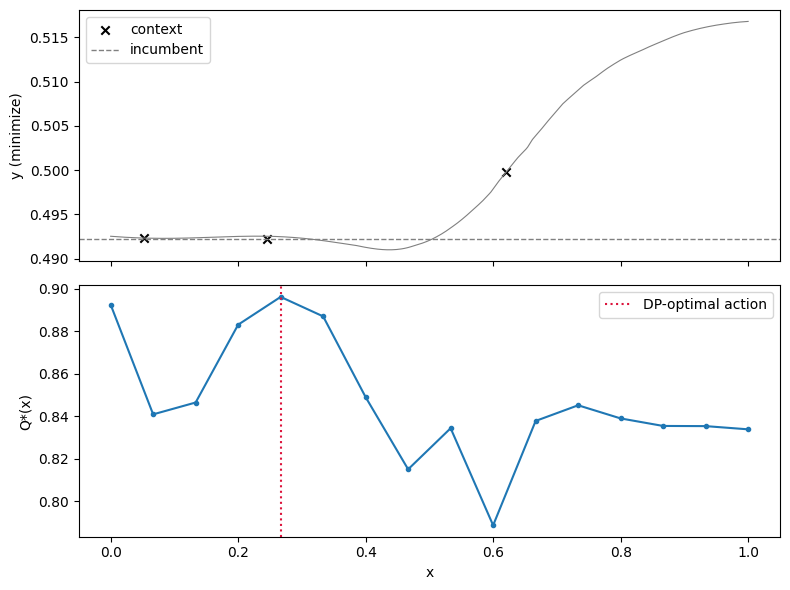

In [2]:
torch.manual_seed(0)
X_DIM, BUDGET, K, N_OUTCOME_BINS = 1, 3, 16, 6

prior = BNNPrior(batch_size=1, x_dim=X_DIM, seed=0)
y_sorted = build_ecdf(prior, n_samples=50_000, seed=1)[0]
x_context, y_context, _, _ = prior.sample_episode(n_train=3, n_test=0)
x_context, y_context = x_context[0], y_context[0]

grid = build_action_grid(d=X_DIM, k=K)
oracle = DiscreteDPOracle(surrogate, y_sorted, grid, n_outcome_bins=N_OUTCOME_BINS)

import time
t0 = time.time()
q_star, v_star = oracle.solve(x_context, y_context, budget=BUDGET)
print(f"solved in {time.time()-t0:.2f}s -- Q* range [{q_star.min().item():.4f}, {q_star.max().item():.4f}], V*={v_star.item():.4f}")

dense_grid = torch.linspace(0, 1, 400).view(-1, 1)
with torch.no_grad():
    y_true = prior.evaluate(dense_grid.unsqueeze(0), noise=False)[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(dense_grid[:, 0], y_true, lw=0.8, color="gray")
ax1.scatter(x_context[:, 0], y_context, color="black", marker="x", label="context")
ax1.axhline(y_context.min().item(), color="gray", ls="--", lw=1, label="incumbent")
ax1.set_ylabel("y (minimize)")
ax1.legend()

ax2.plot(grid[:, 0], q_star, marker="o", ms=3)
ax2.axvline(grid[q_star.argmax(), 0].item(), color="crimson", ls=":", label="DP-optimal action")
ax2.set_xlabel("x")
ax2.set_ylabel("Q*(x)")
ax2.legend()
plt.tight_layout()
plt.show()

## Score candidate Q's against the exact oracle

Exactly what the exit criterion asks for — rank correlation and regret
against `Q*` — exercised now with stand-ins for M4's not-yet-built Q-head:
the PFN's own EI ranking (myopic, 1-step) and a uniform-random ranking (a
floor). This is also a genuinely interesting question in its own right:
does 1-step EI already approximate the 3-step-lookahead optimum well, or
does horizon-awareness change the ranking substantially — directly
relevant to whether M4-M8's whole thesis has room to matter here.

In [3]:
ei, _ = surrogate.expected_improvement(x_context.unsqueeze(0), y_context.unsqueeze(0), grid.unsqueeze(0))
ei = ei[0]

torch.manual_seed(1)
random_q = torch.rand(grid.shape[0])

for name, candidate in [("EI (myopic, 1-step)", ei), ("uniform random", random_q)]:
    result = score_candidate_q(oracle, candidate, x_context, y_context, budget=BUDGET)
    print(f"{name:22s}  spearman_rho={result['spearman_rho']:+.4f}  regret={result['regret']:.4f}")

EI (myopic, 1-step)     spearman_rho=-0.3294  regret=0.0622


uniform random          spearman_rho=+0.0441  regret=0.0091


**One example state, not a systematic claim.** EI came out *negatively*
rank-correlated with the 3-step `Q*` here, and lost to a single random draw
on regret — plausible (M0 already found the AUC-normalized objective more
exploitative than a myopic one would predict, so a real divergence between
1-step EI and a multi-step optimum isn't surprising), and both `oracle.solve`
(cross-checked against an independent brute-force reimplementation) and
`score_candidate_q`'s own math (checked against hand-computed expected
values) are separately verified correct in `tests/test_discrete_dp.py` — so
this isn't a scoring bug. But it's still a single context/seed, and
"random beat EI on regret" is exactly the kind of thing that can flip with
a different draw given only 16 actions. Worth a proper sweep across many
states before treating "EI disagrees with the optimum here" as a finding
about EI in general, rather than about this one state.

## A 2-D case, to confirm the harness isn't 1-D-only

`d=2` (256 actions), `budget=2` — the largest setting that stays fast with
these defaults (see the cost discussion above).

solved in 0.91s -- Q* range [0.7222, 0.8901], V*=0.8901


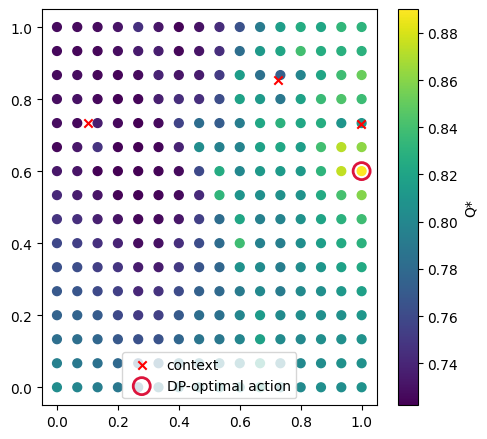

In [4]:
torch.manual_seed(2)
X_DIM_2D, BUDGET_2D = 2, 2

prior_2d = BNNPrior(batch_size=1, x_dim=X_DIM_2D, seed=0)
y_sorted_2d = build_ecdf(prior_2d, n_samples=50_000, seed=1)[0]
x_context_2d, y_context_2d, _, _ = prior_2d.sample_episode(n_train=3, n_test=0)
x_context_2d, y_context_2d = x_context_2d[0], y_context_2d[0]

grid_2d = build_action_grid(d=X_DIM_2D, k=16)
oracle_2d = DiscreteDPOracle(surrogate, y_sorted_2d, grid_2d, n_outcome_bins=N_OUTCOME_BINS)

t0 = time.time()
q_star_2d, v_star_2d = oracle_2d.solve(x_context_2d, y_context_2d, budget=BUDGET_2D)
print(f"solved in {time.time()-t0:.2f}s -- Q* range [{q_star_2d.min().item():.4f}, {q_star_2d.max().item():.4f}], V*={v_star_2d.item():.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
sc = ax.scatter(grid_2d[:, 0], grid_2d[:, 1], c=q_star_2d, cmap="viridis", s=40)
ax.scatter(x_context_2d[:, 0], x_context_2d[:, 1], color="red", marker="x", label="context")
best = grid_2d[q_star_2d.argmax()]
ax.scatter(*best, facecolors="none", edgecolors="crimson", s=150, linewidths=2, label="DP-optimal action")
plt.colorbar(sc, label="Q*")
ax.legend()
plt.tight_layout()
plt.show()

## Exit criterion status

- **`Q*` computed and cached for a fixed seed set** — done above for
  representative `d=1`/`d=2` cases; `DiscreteDPOracle.solve` is
  deterministic given a seed, so re-running this notebook reproduces the
  same numbers (no separate caching layer built yet — add one if repeated
  M4/M5 evaluation runs make recomputation the bottleneck, not before).
- **The harness scores any candidate `Q` by rank correlation and regret
  against the DP-optimal policy** — `score_candidate_q`, exercised above
  against EI and random. Correctness of the solver itself is verified
  independently in `tests/test_discrete_dp.py` (a from-scratch, unbatched
  brute-force reimplementation of the same recursion, cross-checked at
  `budget=1` and `budget=2` — not just "this code doesn't crash").

**A real bug caught while building this**, worth recording: the reward
module's `percentile()` is a plain CDF (high for a *large* value), but
this project minimizes throughout — composing `percentile()` directly into
`g_from_percentile()` silently computes the reward for *maximizing* the
observed value instead. That exact bug was in this module's first draft
(caught by a suspiciously tiny `Q*`) and, on inspection, was also already
present in `reward/tail_quantile_reward.py`'s own `__main__` demo (which
rolls out a *minimizing* EI policy but had been tracking the *maximum*
incumbent) — meaning the clip-bind-rate M1 recorded in `docs/ROADMAP.md`
was measuring the wrong direction. Both are fixed now via one new
canonical function, `g_reward_minimize`, and `docs/ROADMAP.md` §M1 records
the corrected number.